# DX 603: Project Milestone Two: Modeling and Feature Engineering

### Due: Sunday July 26 @ 11:59PM (with grace period of 2 hours & 1 minute)

### Overview

In Milestone 1, you explored the Zillow dataset, cleaned the data, and developed hypotheses about how preprocessing and feature engineering might improve predictive performance.

In this milestone, you will  develop, evaluate, and refine several machine learning models using those ideas. Rather than simply searching for the best algorithm, you will follow an iterative modeling workflow by:

1. Establishing baseline performance using several regression models.
2. Testing the preprocessing and feature engineering ideas proposed in Milestone 1.
3. Refining the feature set through feature selection.
4. Optimizing model performance through hyperparameter tuning.
5. Comparing the evolution of your models and selecting a final model to evaluate on the held-out test set.

Throughout this milestone, use **repeated 5-fold cross-validation (5 repeats)** to guide your modeling decisions. The held-out test set should be used only once, after all modeling decisions have been completed.




In [2]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
#import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
#from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_validate


# Additional imports for hyperparameter tuning
from sklearn.model_selection import KFold, validation_curve
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



/Users/carlos/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Prelude: Load Your Preprocessed Dataset from Milestone 1

In Milestone 1, you cleaned the Zillow dataset by removing unsuitable features, handling missing values, and encoding categorical variables. In this milestone, you will build, compare, and improve several regression models using that prepared dataset.

Begin by returning to your Milestone 1 notebook and rerunning your code through Part 3, where your dataset has been completely cleaned and encoded, but before any experimental feature engineering ideas were evaluated. Save this dataset and use it as the starting point for this milestone.

For example:

```python
# In Milestone 1
df_cleaned.to_csv("zillow_cleaned.csv", index=False)
```

```python
# In Milestone 2
df = pd.read_csv("zillow_cleaned.csv")
```

Next:

1. Separate the predictors (`X`) from the target (`y`).
2. Split the dataset into training and test sets using `train_test_split`.

Some regression models, such as **Ridge Regression** and **Lasso Regression**, require feature scaling. If you use one of these models, standardize the predictor variables **using only the training data**, then apply the same transformation to the test data.

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

**Notes**

- Ordinary Linear Regression, Decision Trees, Random Forests, and HistGradientBoosting do **not** require feature scaling.
- If you create additional features later in this milestone and are using a scaled model, repeat the scaling step so the new features are transformed consistently.
- Throughout this milestone, use the same training/test split so that all models are evaluated on identical data.

In [3]:
# Add as many cells as you need

# Replace 'main' in the base_url if using a different branch.
base_url = (
    'https://raw.githubusercontent.com/'
    'cj6x/DX603S_group_11/refs/heads/main/'
)

X_train = pd.read_csv(base_url + 'X_train.csv')
X_test = pd.read_csv(base_url + 'X_test.csv')

y_train = (
    pd.read_csv(base_url + 'y_train.csv')
    .squeeze('columns')
)

y_test = (
    pd.read_csv(base_url + 'y_test.csv')
    .squeeze('columns')
)

# Keep only numeric features for the three baseline models.
numeric_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

X_train_numeric = X_train[numeric_cols]
X_test_numeric = X_test[numeric_cols]

print("Training feature shape:", X_train_numeric.shape)
print("Test feature shape:", X_test_numeric.shape)

Training feature shape: (61866, 20)
Test feature shape: (15467, 20)


## Problem 1: Model Selection and Baselines [6 pts]

### 1.A Coding

Select **three** regression models from the following list and evaluate each one using the cleaned training dataset.

Use the default hyperparameters provided by scikit-learn (except where scaling is required).

Available models:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Decision Tree Regressor
* Bagging Regressor
* Random Forest Regressor
* HistGradientBoostingRegressor

For each of the three models you choose:

* Train using the **training dataset only**.
* Use **Repeated 5-Fold Cross-Validation** (5 repeats).
* Report validation performance:

  * Mean CV MAE
  * Standard Deviation of CV MAE

In [4]:
# Add as many code cells as needed.

# Evaluation function for the models
def evaluate_model(model, X, y, model_name='Model'):
    cv = RepeatedKFold(
        n_splits=5,
        n_repeats=5,
        random_state=random_state
    )

    scores = cross_val_score(
        estimator=model,
        X=X,
        y=y,
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=-1
    )

    mae_scores = -scores
    mean_mae = np.mean(mae_scores)
    std_mae = np.std(mae_scores)

    print(f'Mean CV MAE of {model_name}: {mean_mae:.4f}')
    print(f'Std Dev CV MAE of {model_name}: {std_mae:.4f}')
    print()

    return mean_mae, std_mae


# Ridge imputation and scaling are kept inside the pipeline.
# This makes them fit separately within each cross-validation fold.
ridge_model = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    Ridge(random_state=random_state)
)

# Use the default max_features setting so the same baseline
# configuration is used throughout the notebook.
rf_model = make_pipeline(
    SimpleImputer(strategy='median'),
    RandomForestRegressor(
        random_state=random_state
    )
)

hgb_model = HistGradientBoostingRegressor(
    random_state=random_state
)

In [5]:
ridge_baseline_mean, ridge_baseline_std = evaluate_model(
    ridge_model,
    X_train_numeric,
    y_train,
    'Ridge Regression'
)

rf_baseline_mean, rf_baseline_std = evaluate_model(
    rf_model,
    X_train_numeric,
    y_train,
    'Random Forest'
)

hgb_baseline_mean, hgb_baseline_std = evaluate_model(
    hgb_model,
    X_train_numeric,
    y_train,
    'HistGradientBoosting'
)


Mean CV MAE of Ridge Regression: 247963.3162
Std Dev CV MAE of Ridge Regression: 2072.9308

Mean CV MAE of Random Forest: 190066.8044
Std Dev CV MAE of Random Forest: 2640.6018

Mean CV MAE of HistGradientBoosting: 193908.4481
Std Dev CV MAE of HistGradientBoosting: 2987.3778



In [6]:
# Compare training and validation MAE for the baseline models.
# To answer 1b3

baseline_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_state
)

def evaluate_train_vs_validation(model, X, y, model_name):
    scores = cross_validate(
        estimator=model,
        X=X,
        y=y,
        scoring="neg_mean_absolute_error",
        cv=baseline_cv,
        return_train_score=True,
        n_jobs=-1
    )

    mean_train_mae = -scores["train_score"].mean()
    mean_validation_mae = -scores["test_score"].mean()

    print(f"{model_name}")
    print(f"Mean training MAE: ${mean_train_mae:,.2f}")
    print(f"Mean validation MAE: ${mean_validation_mae:,.2f}")
    print(
        f"Train-validation gap: "
        f"${mean_validation_mae - mean_train_mae:,.2f}"
    )
    print()

evaluate_train_vs_validation(
    ridge_model,
    X_train_numeric,
    y_train,
    "Ridge Regression"
)

evaluate_train_vs_validation(
    rf_model,
    X_train_numeric,
    y_train,
    "Random Forest"
)

evaluate_train_vs_validation(
    hgb_model,
    X_train_numeric,
    y_train,
    "HistGradientBoosting"
)

Ridge Regression
Mean training MAE: $247,605.94
Mean validation MAE: $247,963.32
Train-validation gap: $357.37

Random Forest
Mean training MAE: $71,471.23
Mean validation MAE: $190,066.80
Train-validation gap: $118,595.57

HistGradientBoosting
Mean training MAE: $182,550.96
Mean validation MAE: $193,908.45
Train-validation gap: $11,357.49



### 1.B Discussion

Answer the following questions.

#### 1.B.1

Which of your three models achieved the **lowest validation MAE score**?

> Random Forest had the lowest validation MAE at $190,066.80. HistGradientBoosting was second at $193,908.45, while Ridge Regression had the highest MAE at $247,963.32. This means Random Forest had the lowest average prediction error out of the three baseline models.

#### 1.B.2

Which model produced the **smallest standard deviation** across the repeated cross-validation runs? What does this suggest about its stability?

> Ridge Regression had the smallest standard deviation at $2,072.93. Random Forest had a standard deviation of $2,640.60, and HistGradientBoosting had the highest at $2,987.38. This suggests that Ridge produced the most consistent results across the different cross-validation splits. However, it was also the least accurate model, so its greater stability did not make up for its much higher MAE.

#### 1.B.3

Did any model appear to overfit or underfit? Explain your reasoning using the training and cross-validation results.

> Random Forest showed the clearest sign of overfitting. Its mean training MAE was $71,471.23, while its mean validation MAE was $190,066.80. This created a large gap of about $118,596, meaning the model performed much better on the training data than on unseen validation data.

> HistGradientBoosting also showed some overfitting, but the gap was much smaller. Its training MAE was $182,550.96 and its validation MAE was $193,908.45, giving a gap of about $11,357.

> Ridge Regression had almost no gap between training and validation performance. Its training MAE was $247,605.94 and its validation MAE was $247,963.32, a difference of only about $357. However, both errors were much higher than the tree-based models. This suggests that Ridge was underfitting because the linear model was not flexible enough to capture the more complex relationships in the data.


#### 1.B.4

Compare the overall strengths and weaknesses of the three models. Did any model consistently perform better, or were there important tradeoffs between accuracy and stability?

> Random Forest performed the best overall because it had the lowest mean CV MAE while still having a reasonably low standard deviation. Its main weakness is that it can take more time and memory to train than a simpler model.
>
> HistGradientBoosting was also strong and its MAE was only about $3,842 higher than Random Forest. However, it had the highest standard deviation, meaning its performance changed slightly more across the different data splits.
>
> Ridge Regression was the most stable model, but it had the highest MAE by a large amount. This suggests that its linear structure was too simple for the relationships in this dataset. Overall, Random Forest gave the best balance between accuracy and stability.

## Part 2: Evaluate Your Feature Engineering Hypotheses [6 pts]

### 2.A Coding

In **Milestone 1**, you proposed several preprocessing and feature engineering ideas that you believed might improve predictive performance.

Select **at least three** of those ideas and evaluate them.

These may include, for example:

* Creating new features
* Transforming existing features
* Removing features
* Combining features
* Other preprocessing ideas that you proposed in Milestone 1

For each idea:

* Apply the preprocessing or feature engineering to the **training dataset only**.
* Retrain the same three baseline models from **Problem 1** using repeated 5-fold cross-validation (5 repeats).
* Compare the validation performance (mean CV MAE) and stability (standard deviation of CV MAE) with your original baseline results


> One of the most important things you can learn is that **not every clever idea results in an improvement**--they have to be evaluated by careful experiment.  And negative results are valuable if they are carefully evaluated and discussed!

In [7]:
# ==============================================
# Hypothesis 1: Remove Correlated Features
# ==============================================

# Identify highly correlated numeric feature pairs.
corr = X_train_numeric.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .loc[lambda values: values > 0.90]
    .sort_values(ascending=False)
)

print("Highly correlated feature pairs:")
print(high_corr_pairs)
print()

# Keep bathroomcnt and calculatedfinishedsquarefeet.
# Remove their highly correlated alternatives.
correlated_features_to_remove = [
    "calculatedbathnbr",
    "fullbathcnt",
    "finishedsquarefeet12"
]

X_train_corr_removed = X_train_numeric.drop(
    columns=correlated_features_to_remove
)

ridge_corr_mean, ridge_corr_std = evaluate_model(
    ridge_model,
    X_train_corr_removed,
    y_train,
    "Ridge Regression (Correlated Features Removed)"
)

rf_corr_mean, rf_corr_std = evaluate_model(
    rf_model,
    X_train_corr_removed,
    y_train,
    "Random Forest (Correlated Features Removed)"
)

hgb_corr_mean, hgb_corr_std = evaluate_model(
    hgb_model,
    X_train_corr_removed,
    y_train,
    "HistGradientBoosting (Correlated Features Removed)"
)

Highly correlated feature pairs:
bathroomcnt                   calculatedbathnbr       0.990349
calculatedbathnbr             fullbathcnt             0.984666
bathroomcnt                   fullbathcnt             0.974604
calculatedfinishedsquarefeet  finishedsquarefeet12    0.957454
dtype: float64

Mean CV MAE of Ridge Regression (Correlated Features Removed): 248962.4802
Std Dev CV MAE of Ridge Regression (Correlated Features Removed): 2158.4804

Mean CV MAE of Random Forest (Correlated Features Removed): 190361.1192
Std Dev CV MAE of Random Forest (Correlated Features Removed): 2900.0372

Mean CV MAE of HistGradientBoosting (Correlated Features Removed): 193641.7926
Std Dev CV MAE of HistGradientBoosting (Correlated Features Removed): 3018.4668



In [8]:
# ==============================================
# Hypothesis 2: Log-Transform the Target
# ==============================================

# Each model is trained using log1p(y).
# Predictions are converted back to the original dollar scale
# before MAE is calculated.
ridge_log_model = TransformedTargetRegressor(
    regressor=ridge_model,
    func=np.log1p,
    inverse_func=np.expm1
)

rf_log_model = TransformedTargetRegressor(
    regressor=rf_model,
    func=np.log1p,
    inverse_func=np.expm1
)

hgb_log_model = TransformedTargetRegressor(
    regressor=hgb_model,
    func=np.log1p,
    inverse_func=np.expm1
)

ridge_log_mean, ridge_log_std = evaluate_model(
    ridge_log_model,
    X_train_numeric,
    y_train,
    "Ridge Regression (Log Target)"
)

rf_log_mean, rf_log_std = evaluate_model(
    rf_log_model,
    X_train_numeric,
    y_train,
    "Random Forest (Log Target)"
)

hgb_log_mean, hgb_log_std = evaluate_model(
    hgb_log_model,
    X_train_numeric,
    y_train,
    "HistGradientBoosting (Log Target)"
)

Mean CV MAE of Ridge Regression (Log Target): 330575.7200
Std Dev CV MAE of Ridge Regression (Log Target): 101975.3839

Mean CV MAE of Random Forest (Log Target): 195196.9085
Std Dev CV MAE of Random Forest (Log Target): 3242.2215

Mean CV MAE of HistGradientBoosting (Log Target): 194648.4402
Std Dev CV MAE of HistGradientBoosting (Log Target): 3326.4758



In [9]:
# ==============================================
# Hypothesis 3: Size-Bathroom Interaction
# ==============================================

X_train_interaction = X_train_numeric.copy()

# This directly tests the Milestone 1 idea of combining
# home size with bathroom count.
X_train_interaction["size_bath_interaction"] = (
    X_train_interaction["calculatedfinishedsquarefeet"]
    * X_train_interaction["bathroomcnt"]
)

ridge_interaction_mean, ridge_interaction_std = evaluate_model(
    ridge_model,
    X_train_interaction,
    y_train,
    "Ridge Regression (Size-Bathroom Interaction)"
)

rf_interaction_mean, rf_interaction_std = evaluate_model(
    rf_model,
    X_train_interaction,
    y_train,
    "Random Forest (Size-Bathroom Interaction)"
)

hgb_interaction_mean, hgb_interaction_std = evaluate_model(
    hgb_model,
    X_train_interaction,
    y_train,
    "HistGradientBoosting (Size-Bathroom Interaction)"
)

Mean CV MAE of Ridge Regression (Size-Bathroom Interaction): 231887.1829
Std Dev CV MAE of Ridge Regression (Size-Bathroom Interaction): 2702.3598

Mean CV MAE of Random Forest (Size-Bathroom Interaction): 190086.9329
Std Dev CV MAE of Random Forest (Size-Bathroom Interaction): 2677.7402

Mean CV MAE of HistGradientBoosting (Size-Bathroom Interaction): 194166.5364
Std Dev CV MAE of HistGradientBoosting (Size-Bathroom Interaction): 3333.0667



In [10]:
# ==============================================
# Part 2 Results Comparison
# ==============================================

part2_results = pd.DataFrame([
    {
        "Model": "Ridge Regression",
        "Experiment": "Baseline",
        "Mean CV MAE": ridge_baseline_mean,
        "Std Dev CV MAE": ridge_baseline_std
    },
    {
        "Model": "Random Forest",
        "Experiment": "Baseline",
        "Mean CV MAE": rf_baseline_mean,
        "Std Dev CV MAE": rf_baseline_std
    },
    {
        "Model": "HistGradientBoosting",
        "Experiment": "Baseline",
        "Mean CV MAE": hgb_baseline_mean,
        "Std Dev CV MAE": hgb_baseline_std
    },

    {
        "Model": "Ridge Regression",
        "Experiment": "Correlated Features Removed",
        "Mean CV MAE": ridge_corr_mean,
        "Std Dev CV MAE": ridge_corr_std
    },
    {
        "Model": "Random Forest",
        "Experiment": "Correlated Features Removed",
        "Mean CV MAE": rf_corr_mean,
        "Std Dev CV MAE": rf_corr_std
    },
    {
        "Model": "HistGradientBoosting",
        "Experiment": "Correlated Features Removed",
        "Mean CV MAE": hgb_corr_mean,
        "Std Dev CV MAE": hgb_corr_std
    },

    {
        "Model": "Ridge Regression",
        "Experiment": "Log-Transformed Target",
        "Mean CV MAE": ridge_log_mean,
        "Std Dev CV MAE": ridge_log_std
    },
    {
        "Model": "Random Forest",
        "Experiment": "Log-Transformed Target",
        "Mean CV MAE": rf_log_mean,
        "Std Dev CV MAE": rf_log_std
    },
    {
        "Model": "HistGradientBoosting",
        "Experiment": "Log-Transformed Target",
        "Mean CV MAE": hgb_log_mean,
        "Std Dev CV MAE": hgb_log_std
    },

    {
        "Model": "Ridge Regression",
        "Experiment": "Size-Bathroom Interaction",
        "Mean CV MAE": ridge_interaction_mean,
        "Std Dev CV MAE": ridge_interaction_std
    },
    {
        "Model": "Random Forest",
        "Experiment": "Size-Bathroom Interaction",
        "Mean CV MAE": rf_interaction_mean,
        "Std Dev CV MAE": rf_interaction_std
    },
    {
        "Model": "HistGradientBoosting",
        "Experiment": "Size-Bathroom Interaction",
        "Mean CV MAE": hgb_interaction_mean,
        "Std Dev CV MAE": hgb_interaction_std
    }
])

part2_results["MAE Change vs Baseline"] = (
    part2_results["Mean CV MAE"]
    - part2_results.groupby("Model")["Mean CV MAE"].transform("first")
)

display(
    part2_results.style.format({
        "Mean CV MAE": "${:,.2f}",
        "Std Dev CV MAE": "${:,.2f}",
        "MAE Change vs Baseline": "${:+,.2f}"
    })
)

,Model,Experiment,Mean CV MAE,Std Dev CV MAE,MAE Change vs Baseline
0,Ridge Regression,Baseline,"$247,963.32","$2,072.93",$+0.00
1,Random Forest,Baseline,"$190,066.80","$2,640.60",$+0.00
2,HistGradientBoosting,Baseline,"$193,908.45","$2,987.38",$+0.00
3,Ridge Regression,Correlated Features Removed,"$248,962.48","$2,158.48",$+999.16
4,Random Forest,Correlated Features Removed,"$190,361.12","$2,900.04",$+294.31
5,HistGradientBoosting,Correlated Features Removed,"$193,641.79","$3,018.47",$-266.66
6,Ridge Regression,Log-Transformed Target,"$330,575.72","$101,975.38","$+82,612.40"
7,Random Forest,Log-Transformed Target,"$195,196.91","$3,242.22","$+5,130.10"
8,HistGradientBoosting,Log-Transformed Target,"$194,648.44","$3,326.48",$+739.99
9,Ridge Regression,Size-Bathroom Interaction,"$231,887.18","$2,702.36","$-16,076.13"


### 2.B Discussion

Answer the following questions.

#### 2.B.1

Which of your feature engineering ideas produced the largest improvement in validation performance?

> The size-bathroom interaction produced the largest improvement. For Ridge Regression, the mean CV MAE decreased from $247,963.32 to $231,887.18. This was an improvement of about $16,076, or 6.48%.

Removing correlated features also slightly improved HistGradientBoosting. Its MAE decreased from $193,908.45 to $193,641.79, which was an improvement of about $267. However, this improvement was much smaller than the improvement seen for Ridge with the interaction feature.

The size-bathroom interaction probably helped Ridge because a linear model cannot automatically capture this type of combined relationship. Adding the interaction gave Ridge a way to account for how property size and bathroom count work together.

#### 2.B.2

Were any of your ideas unsuccessful or did they reduce model performance? Briefly explain.

> The log transformation of the target was the least successful idea because it made all three models worse. Ridge Regression was affected the most, with its MAE increasing from $247,963.32 to $330,575.72. Random Forest increased by about $5,130, and HistGradientBoosting increased by about $740.

Removing correlated features also made Ridge and Random Forest slightly worse, although it slightly improved HistGradientBoosting. The size-bathroom interaction improved Ridge, but it did not improve the two tree-based models. Random Forest became worse by only about $20, while HistGradientBoosting became worse by about $258.

This shows that the same feature engineering idea did not affect every model in the same way.

#### 2.B.3

Did some models benefit more from feature engineering than others? If so, why do you think this occurred?

> Ridge Regression benefited the most from feature engineering. The size-bathroom interaction reduced its MAE by about $16,076. I think this happened because Ridge is a linear model and cannot create more complex interactions on its own. Adding the interaction feature gave it information that was not directly available from the two features separately.

The tree-based models did not benefit from the interaction feature because they can already capture nonlinear relationships and interactions through their splits. HistGradientBoosting did slightly improve when the correlated features were removed, but the improvement was only about $267 and its standard deviation also increased slightly.

Overall, the feature engineering changes had a much larger effect on Ridge than on Random Forest or HistGradientBoosting.

#### 2.B.4

Which preprocessing or feature engineering changes will you keep for the remainder of the milestone? Briefly justify your decision.

> I will keep the size-bathroom interaction for Ridge Regression because it produced a clear improvement in validation MAE. For Random Forest and HistGradientBoosting, I will continue using the original feature set because the interaction feature did not improve either model.

I will not keep the log transformation of the target because it made all three models worse. I also will not remove the correlated features for the remainder of the milestone. Although this slightly improved HistGradientBoosting, the improvement was only about $267 and was small compared to the variation across the cross-validation runs.

This means Ridge will use the interaction dataset, while Random Forest and HistGradientBoosting will use the original features going into Part 3.

## Part 3: Refine the Feature Set [6 pts]

### 3.A Coding

Using your dataset after completing **Part 2** (including any preprocessing and feature engineering changes you decided to keep):

Investigate whether **feature selection** can further improve model performance.

You may use one or more of the following methods:

* Forward Selection (for linear regression models)
* Backward Selection (for linear regression models)
* Feature importance from tree-based models (for decision trees, Random Forests, Bagging, and HistGradientBoosting)
* Another reasonable feature selection method

For each of your three models:

* Select a subset of features using an appropriate feature selection method.
* Retrain the model using only the selected features.
* Evaluate the model using the same repeated cross-validation procedure as before.
* Report the validation performance (the mean and standard deviation of the CV MAE).

> Not every model will necessarily benefit from feature selection. Choose methods that are appropriate for the models you selected. Negative results are valuable if they are carefully evaluated and discussed!

In [11]:
# ==============================================
# Part 3: Starting Datasets After Part 2
# ==============================================

# The size-bathroom interaction improved Ridge, so Ridge
# starts Part 3 with that feature included.
X_train_ridge_base = X_train_interaction.copy()

# The original feature set performed best for both tree models.
X_train_tree_base = X_train_numeric.copy()

print(
    "Ridge starting number of features:",
    X_train_ridge_base.shape[1]
)

print(
    "Tree-model starting number of features:",
    X_train_tree_base.shape[1]
)

Ridge starting number of features: 21
Tree-model starting number of features: 20


In [12]:
# ==============================================
# Ridge Regression Feature Selection
# ==============================================

# Use forward selection to select 10 features.
# The scoring metric is MAE so it matches the metric
# used throughout the notebook.
sfs_ridge = SequentialFeatureSelector(
    estimator=ridge_model,
    n_features_to_select=10,
    direction="forward",
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1
)

sfs_ridge.fit(
    X_train_ridge_base,
    y_train
)

selected_features_ridge = (
    X_train_ridge_base.columns[
        sfs_ridge.get_support()
    ].tolist()
)

print("Selected features for Ridge:")

for feature in selected_features_ridge:
    print(f"- {feature}")

print()

# Create the Ridge feature-selected dataset.
X_train_ridge_sel = X_train_ridge_base[
    selected_features_ridge
]

# Evaluate Ridge using only the selected features.
ridge_selected_mean, ridge_selected_std = evaluate_model(
    ridge_model,
    X_train_ridge_sel,
    y_train,
    "Ridge Regression (Feature Selected)"
)

Selected features for Ridge:
- bathroomcnt
- calculatedbathnbr
- heatingorsystemtypeid
- latitude
- longitude
- lotsizesquarefeet
- propertylandusetypeid
- unitcnt
- assessmentyear
- size_bath_interaction

Mean CV MAE of Ridge Regression (Feature Selected): 233262.1018
Std Dev CV MAE of Ridge Regression (Feature Selected): 2678.5828



In [13]:
# ==============================================
# Tree-Based Feature Selection
# ==============================================

# Fit a separate Random Forest pipeline to calculate
# feature importances from the original tree-model dataset.
rf_selector = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1
    )
)

rf_selector.fit(
    X_train_tree_base,
    y_train
)

# Retrieve feature importances from the fitted
# Random Forest inside the pipeline.
tree_importances = (
    rf_selector
    .named_steps["randomforestregressor"]
    .feature_importances_
)

fi_df = pd.DataFrame({
    "Feature": X_train_tree_base.columns,
    "Importance": tree_importances
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(fi_df)

# Keep the top 12 features for the tree-based models.
top_tree_features = (
    fi_df.head(12)["Feature"].tolist()
)

print("Selected top features for the tree models:")

for feature in top_tree_features:
    print(f"- {feature}")

,Feature,Importance
0,finishedsquarefeet12,0.325893
1,calculatedfinishedsquarefeet,0.137581
2,regionidzip,0.083715
3,longitude,0.081888
4,latitude,0.080691
5,lotsizesquarefeet,0.063677
6,yearbuilt,0.057615
7,bedroomcnt,0.029593
8,buildingqualitytypeid,0.028614
9,fullbathcnt,0.026810


Selected top features for the tree models:
- finishedsquarefeet12
- calculatedfinishedsquarefeet
- regionidzip
- longitude
- latitude
- lotsizesquarefeet
- yearbuilt
- bedroomcnt
- buildingqualitytypeid
- fullbathcnt
- bathroomcnt
- regionidcity


In [14]:
# ==============================================
# Evaluate Tree Models After Feature Selection
# ==============================================

X_train_tree_sel = X_train_tree_base[
    top_tree_features
]

rf_selected_mean, rf_selected_std = evaluate_model(
    rf_model,
    X_train_tree_sel,
    y_train,
    "Random Forest (Feature Selected)"
)

hgb_selected_mean, hgb_selected_std = evaluate_model(
    hgb_model,
    X_train_tree_sel,
    y_train,
    "HistGradientBoosting (Feature Selected)"
)

Mean CV MAE of Random Forest (Feature Selected): 190301.7784
Std Dev CV MAE of Random Forest (Feature Selected): 2745.8006

Mean CV MAE of HistGradientBoosting (Feature Selected): 194420.7363
Std Dev CV MAE of HistGradientBoosting (Feature Selected): 3265.8231



In [15]:
# ==============================================
# Part 3 Results Comparison
# ==============================================

# Ridge is compared against its retained Part 2 version,
# which includes the size-bathroom interaction.
#
# The two tree models are compared against their original
# Part 1 baselines because no Part 2 change was retained.

part3_results = pd.DataFrame([
    {
        "Model": "Ridge Regression",
        "Retained Part 2 Mean CV MAE": ridge_interaction_mean,
        "Retained Part 2 Std Dev": ridge_interaction_std,
        "Feature-Selected Mean CV MAE": ridge_selected_mean,
        "Feature-Selected Std Dev": ridge_selected_std
    },
    {
        "Model": "Random Forest",
        "Retained Part 2 Mean CV MAE": rf_baseline_mean,
        "Retained Part 2 Std Dev": rf_baseline_std,
        "Feature-Selected Mean CV MAE": rf_selected_mean,
        "Feature-Selected Std Dev": rf_selected_std
    },
    {
        "Model": "HistGradientBoosting",
        "Retained Part 2 Mean CV MAE": hgb_baseline_mean,
        "Retained Part 2 Std Dev": hgb_baseline_std,
        "Feature-Selected Mean CV MAE": hgb_selected_mean,
        "Feature-Selected Std Dev": hgb_selected_std
    }
])

part3_results["MAE Change After Feature Selection"] = (
    part3_results["Feature-Selected Mean CV MAE"]
    - part3_results["Retained Part 2 Mean CV MAE"]
)

display(
    part3_results.style.format({
        "Retained Part 2 Mean CV MAE": "${:,.2f}",
        "Retained Part 2 Std Dev": "${:,.2f}",
        "Feature-Selected Mean CV MAE": "${:,.2f}",
        "Feature-Selected Std Dev": "${:,.2f}",
        "MAE Change After Feature Selection": "${:+,.2f}"
    })
)

,Model,Retained Part 2 Mean CV MAE,Retained Part 2 Std Dev,Feature-Selected Mean CV MAE,Feature-Selected Std Dev,MAE Change After Feature Selection
0,Ridge Regression,"$231,887.18","$2,702.36","$233,262.10","$2,678.58","$+1,374.92"
1,Random Forest,"$190,066.80","$2,640.60","$190,301.78","$2,745.80",$+234.97
2,HistGradientBoosting,"$193,908.45","$2,987.38","$194,420.74","$3,265.82",$+512.29


#### 3.B.1

Did feature selection improve the validation performance of any of your models?

> Feature selection did not improve the validation MAE for any of the three models.

|Model|Before Feature Selection|After Feature Selection|Change in MAE|
|---|---:|---:|---:|
|Ridge Regression|$231,887.18|$233,262.10|+$1,374.92|
|Random Forest|$190,066.80|$190,301.78|+$234.97|
|HistGradientBoosting|$193,908.45|$194,420.74|+$512.29|

Random Forest had the smallest decrease in performance, with its MAE increasing by only about $235, or 0.12%. Ridge had the largest increase at about $1,375, or 0.59%. Even though the results were slightly worse, the differences were fairly small compared to the number of features removed.



#### 3.B.2

Which features were consistently selected across the different methods?

> Four features were selected by both the Ridge forward selection method and the Random Forest importance method:

- bathroomcnt
- latitude
- longitude
- lotsizesquarefeet

These features describe the number of bathrooms, the location of the property, and the lot size. Since both selection methods kept them, they appear to provide useful information across both linear and tree-based models.

The methods also selected some different features. Ridge selected variables such as calculatedbathnbr, unitcnt, propertylandusetypeid, and the size-bath interaction. The tree-based method selected more property-size and location variables, including finishedsquarefeet12, calculatedfinishedsquarefeet, regionidzip, yearbuilt, and regionidcity.

#### 3.B.3

Were any of your engineered features selected as important? If so, what does this suggest about the hypotheses you developed in Milestone 1?

> Yes. The size-bath interaction feature was selected as one of the 10 Ridge features. This supports the Milestone 1 hypothesis that combining home size and bathroom count could provide additional predictive information.

The interaction also improved Ridge during Part 2, reducing its MAE by about $16,076 compared to the original Ridge baseline. This makes sense because Ridge is a linear model and cannot automatically capture that type of interaction unless it is added as a separate feature.

The other two hypotheses involved removing existing correlated variables and transforming the target, so they did not create new features that could appear in the selected feature list.

#### 3.B.4

Would you keep the selected features for the rest of the project? Why or why not?

> I would keep the selected feature sets for the rest of the project. Feature selection caused a small increase in MAE for all three models, but it also reduced Ridge from 21 features to 10 and reduced the tree-based models from 20 features to 12.

Random Forest only became worse by about $235, and HistGradientBoosting became worse by about $512. Ridge became worse by about $1,375, but it still performed much better than the original Ridge model because the selected feature set kept the size-bath interaction.

The smaller feature sets should make the models easier to understand and require less time and memory to train. The trade-off is a small loss in accuracy, but the difference was small enough that I would continue with the selected features.

## Part 4: Tune Your Models [8 pts]

### 4.A Coding

Using the three models developed in **Part 3** (including your final preprocessing, feature engineering, and feature selection decisions):

Investigate whether **hyperparameter tuning** can further improve model performance.

For each of your three models:

* Select one or more important hyperparameters to tune.
* Use one or more appropriate tuning methods. Consider first using validation curves (`sweep_parameter`) to identify a promising region or performance plateau, followed by a focused search using methods such as:

    * GridSearchCV
    * RandomizedSearchCV
    * Another reasonable hyperparameter search method

* Choose hyperparameter values based on the validation results. If several nearby values produce similar validation performance (a performance plateau), prefer **values near the beginning of the plateau,** since they often produce simpler models with nearly identical predictive performance.
* Retrain the model using those hyperparameters.
* Evaluate the tuned model using repeated 5-fold cross-validation (5 repeats).
* Report the validation performance (**mean** and **standard deviation** of the CV MAE).


In [16]:


# Use a smaller CV during hyperparameter searching to control runtime.
# The final models will still be evaluated using the required
# repeated 5-fold cross-validation with 5 repeats.
tuning_cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=random_state
)


def sweep_parameter(model, X, y, param_name, param_values, model_name):
    """
    Create a validation curve for one hyperparameter.

    Returns a DataFrame containing the training and validation MAE
    for each parameter value.
    """

    train_scores, validation_scores = validation_curve(
        estimator=model,
        X=X,
        y=y,
        param_name=param_name,
        param_range=param_values,
        scoring="neg_mean_absolute_error",
        cv=tuning_cv,
        n_jobs=-1
    )

    results = pd.DataFrame({
        "parameter_value": param_values,
        "mean_train_mae": -train_scores.mean(axis=1),
        "mean_cv_mae": -validation_scores.mean(axis=1),
        "std_cv_mae": validation_scores.std(axis=1)
    })

    display(results)

    # Use numeric positions so logarithmic and categorical values
    # are displayed clearly.
    positions = np.arange(len(param_values))

    plt.figure(figsize=(9, 5))

    plt.plot(
        positions,
        results["mean_train_mae"],
        marker="o",
        label="Training MAE"
    )

    plt.errorbar(
        positions,
        results["mean_cv_mae"],
        yerr=results["std_cv_mae"],
        marker="o",
        capsize=4,
        label="Validation MAE"
    )

    plt.xticks(
        positions,
        [str(value) for value in param_values],
        rotation=45
    )

    plt.xlabel(param_name)
    plt.ylabel("Mean Absolute Error")
    plt.title(f"{model_name}: Validation Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results


def beginning_of_plateau(results, tolerance=0.0025):
    """
    Select the first parameter value whose validation MAE is within
    0.25% of the best validation MAE.

    This follows the instruction to prefer a simpler value near the
    beginning of a performance plateau.
    """

    best_mae = results["mean_cv_mae"].min()
    plateau_limit = best_mae * (1 + tolerance)

    plateau_results = results[
        results["mean_cv_mae"] <= plateau_limit
    ]

    return plateau_results.iloc[0]["parameter_value"]


# Recreate the final Part 3 models.
# Preprocessing remains inside the pipelines so it occurs separately
# within every cross-validation fold.

ridge_part3 = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    Ridge(random_state=random_state)
)

# Keep the forest single-threaded because GridSearchCV and
# cross-validation will handle parallel processing.
rf_part3 = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestRegressor(
        random_state=random_state,
        n_jobs=1
    )
)

# HistGradientBoosting can handle missing numeric values directly.
# Turning off early stopping allows max_iter to be evaluated consistently.
hgb_part3 = HistGradientBoostingRegressor(
    random_state=random_state,
    early_stopping=False
)

,parameter_value,mean_train_mae,mean_cv_mae,std_cv_mae
0,0.001000,232289.377538,232902.008251,1505.924862
1,0.004642,232289.366114,232901.996342,1505.924504
2,0.021544,232289.313095,232901.941080,1505.922837
3,0.100000,232289.067034,232901.684626,1505.915100
4,0.464159,232287.926073,232900.494944,1505.879236
5,2.154435,232282.644828,232894.990768,1505.718441
6,10.000000,232258.944867,232871.172035,1505.764952
7,46.415888,232167.035751,232774.643351,1510.134124
8,215.443469,231884.494461,232483.205677,1534.444672
9,1000.000000,231223.346972,231866.061999,1386.023713


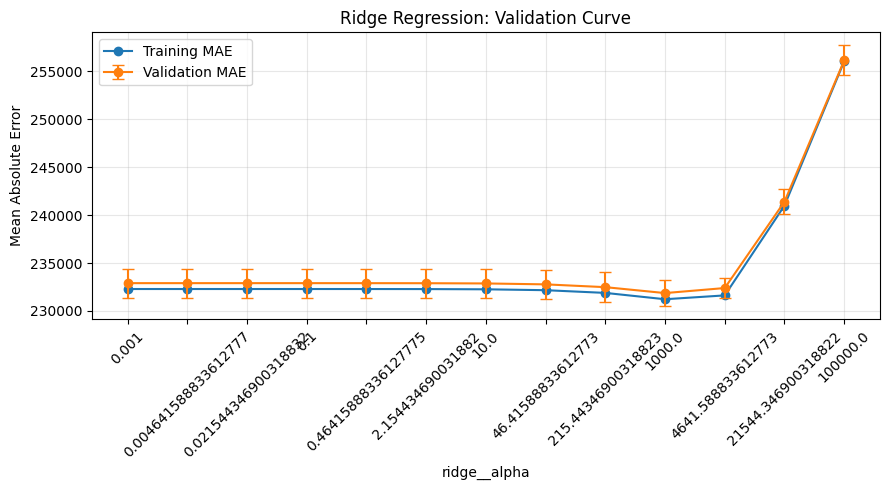

Best Ridge parameters:
{'ridge__alpha': np.float64(2000.0)}
Ridge tuning CV MAE: $231,552.34


In [17]:
# ==========================================
# Ridge Regression Hyperparameter Tuning
# ==========================================

# Alpha controls the strength of Ridge's L2 regularization.
ridge_alpha_values = np.logspace(-3, 5, 13)

ridge_sweep = sweep_parameter(
    model=ridge_part3,
    X=X_train_ridge_sel,
    y=y_train,
    param_name="ridge__alpha",
    param_values=ridge_alpha_values,
    model_name="Ridge Regression"
)

# Identify the best general region from the validation curve.
ridge_best_alpha = float(
    ridge_sweep.loc[
        ridge_sweep["mean_cv_mae"].idxmin(),
        "parameter_value"
    ]
)

# Conduct a focused search around the best alpha.
ridge_focused_alphas = np.unique(
    ridge_best_alpha * np.array([
        0.25,
        0.50,
        1.00,
        2.00,
        4.00
    ])
)

ridge_search = GridSearchCV(
    estimator=ridge_part3,
    param_grid={
        "ridge__alpha": ridge_focused_alphas
    },
    scoring="neg_mean_absolute_error",
    cv=tuning_cv,
    n_jobs=-1,
    refit=True
)

ridge_search.fit(
    X_train_ridge_sel,
    y_train
)

print("Best Ridge parameters:")
print(ridge_search.best_params_)

print(
    f"Ridge tuning CV MAE: "
    f"${-ridge_search.best_score_:,.2f}"
)

tuned_ridge = ridge_search.best_estimator_

,parameter_value,mean_train_mae,mean_cv_mae,std_cv_mae
0,5,214269.548563,218696.036005,1933.161183
1,10,174385.070121,195038.115757,1561.534393
2,15,135766.754981,189926.993459,1168.965844
3,20,100127.798546,189851.455126,996.422756
4,25,80511.393724,190466.045122,1167.491652
5,30,73794.466080,190919.235572,1127.160439


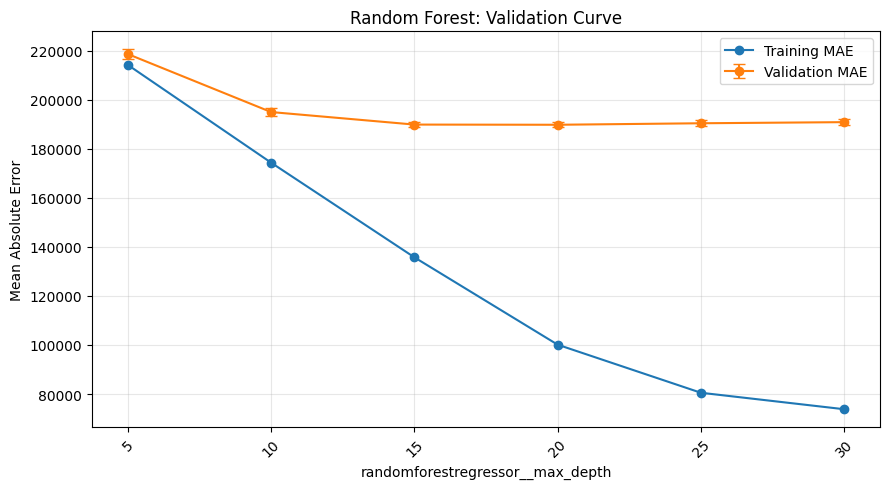

Random Forest depth selected from validation curve: 15
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Random Forest parameters:
{'randomforestregressor__n_estimators': 200, 'randomforestregressor__min_samples_leaf': 4, 'randomforestregressor__max_features': 0.75, 'randomforestregressor__max_depth': 15}
Random Forest tuning CV MAE: $189,129.05


In [18]:
# ==========================================
# Random Forest Hyperparameter Tuning
# ==========================================

# First sweep max_depth to find a promising region.
rf_depth_values = [5, 10, 15, 20, 25, 30]

rf_depth_sweep = sweep_parameter(
    model=rf_part3,
    X=X_train_tree_sel,
    y=y_train,
    param_name="randomforestregressor__max_depth",
    param_values=rf_depth_values,
    model_name="Random Forest"
)

# Select the shallower depth near the beginning of the plateau.
rf_plateau_depth = int(
    beginning_of_plateau(
        rf_depth_sweep,
        tolerance=0.0025
    )
)

print(
    "Random Forest depth selected from validation curve:",
    rf_plateau_depth
)

# Search around the promising depth while also tuning other
# important Random Forest hyperparameters.
rf_depth_candidates = list(dict.fromkeys([
    max(3, rf_plateau_depth - 5),
    rf_plateau_depth,
    rf_plateau_depth + 5,
    None
]))

rf_parameter_distribution = {
    "randomforestregressor__n_estimators": [
        100,
        150,
        200
    ],
    "randomforestregressor__max_depth":
        rf_depth_candidates,
    "randomforestregressor__min_samples_leaf": [
        1,
        2,
        4,
        8
    ],
    "randomforestregressor__max_features": [
        0.50,
        0.75,
        1.00
    ]
}

rf_search = RandomizedSearchCV(
    estimator=rf_part3,
    param_distributions=rf_parameter_distribution,
    n_iter=12,
    scoring="neg_mean_absolute_error",
    cv=tuning_cv,
    random_state=random_state,
    n_jobs=-1,
    refit=True,
    verbose=1
)

rf_search.fit(
    X_train_tree_sel,
    y_train
)

print("\nBest Random Forest parameters:")
print(rf_search.best_params_)

print(
    f"Random Forest tuning CV MAE: "
    f"${-rf_search.best_score_:,.2f}"
)

tuned_rf = rf_search.best_estimator_

,parameter_value,mean_train_mae,mean_cv_mae,std_cv_mae
0,50,183790.633880,194801.654853,1497.830246
1,100,175787.927816,192669.647792,1433.794899
2,150,170383.363109,192013.575424,1230.962438
3,200,166032.756602,191831.418892,1348.627990
4,300,159037.897985,191797.842444,1333.991561
5,400,153436.135673,191885.753149,1291.220445


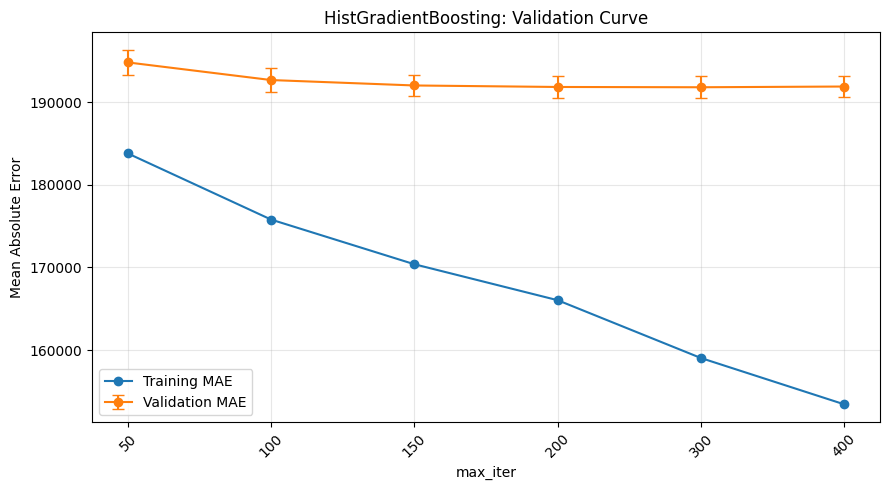

HistGradientBoosting iteration count selected from validation curve: 150
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best HistGradientBoosting parameters:
{'min_samples_leaf': 10, 'max_leaf_nodes': 31, 'max_iter': 250, 'learning_rate': 0.08, 'l2_regularization': 5.0}
HistGradientBoosting tuning CV MAE: $190,941.78


In [19]:
# ===============================================
# HistGradientBoosting Hyperparameter Tuning
# ===============================================

# First sweep the number of boosting iterations.
hgb_iteration_values = [
    50,
    100,
    150,
    200,
    300,
    400
]

hgb_iteration_sweep = sweep_parameter(
    model=hgb_part3,
    X=X_train_tree_sel,
    y=y_train,
    param_name="max_iter",
    param_values=hgb_iteration_values,
    model_name="HistGradientBoosting"
)

# Choose the earliest iteration count near the performance plateau.
hgb_plateau_iteration = int(
    beginning_of_plateau(
        hgb_iteration_sweep,
        tolerance=0.0025
    )
)

print(
    "HistGradientBoosting iteration count selected "
    "from validation curve:",
    hgb_plateau_iteration
)

hgb_iteration_candidates = sorted(set([
    max(50, hgb_plateau_iteration - 50),
    hgb_plateau_iteration,
    hgb_plateau_iteration + 50,
    hgb_plateau_iteration + 100
]))

hgb_parameter_distribution = {
    "learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10
    ],
    "max_iter": hgb_iteration_candidates,
    "max_leaf_nodes": [
        15,
        31,
        63
    ],
    "min_samples_leaf": [
        10,
        20,
        30
    ],
    "l2_regularization": [
        0.0,
        0.1,
        1.0,
        5.0
    ]
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_part3,
    param_distributions=hgb_parameter_distribution,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=tuning_cv,
    random_state=random_state,
    n_jobs=-1,
    refit=True,
    verbose=1
)

hgb_search.fit(
    X_train_tree_sel,
    y_train
)

print("\nBest HistGradientBoosting parameters:")
print(hgb_search.best_params_)

print(
    f"HistGradientBoosting tuning CV MAE: "
    f"${-hgb_search.best_score_:,.2f}"
)

tuned_hgb = hgb_search.best_estimator_

In [20]:
# ==================================================
# Final Evaluation: Repeated 5-Fold CV, 5 Repeats
# ==================================================

final_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_state
)


def evaluate_tuned_model(model, X, y, model_name):
    """
    Evaluate a tuned model using the required repeated
    5-fold cross-validation with 5 repeats.
    """

    scores = cross_val_score(
        estimator=model,
        X=X,
        y=y,
        scoring="neg_mean_absolute_error",
        cv=final_cv,
        n_jobs=-1
    )

    mae_scores = -scores

    mean_mae = mae_scores.mean()
    std_mae = mae_scores.std()

    print(f"Mean CV MAE of {model_name}: ${mean_mae:,.2f}")
    print(f"Std Dev CV MAE of {model_name}: ${std_mae:,.2f}")
    print()

    return {
        "Model": model_name,
        "Mean CV MAE": mean_mae,
        "Std Dev CV MAE": std_mae
    }


tuned_results = pd.DataFrame([
    evaluate_tuned_model(
        model=tuned_ridge,
        X=X_train_ridge_sel,
        y=y_train,
        model_name="Ridge Regression (Tuned)"
    ),

    evaluate_tuned_model(
        model=tuned_rf,
        X=X_train_tree_sel,
        y=y_train,
        model_name="Random Forest (Tuned)"
    ),

    evaluate_tuned_model(
        model=tuned_hgb,
        X=X_train_tree_sel,
        y=y_train,
        model_name="HistGradientBoosting (Tuned)"
    )
])

print("Final tuned-model results:")
display(
    tuned_results.style.format({
        "Mean CV MAE": "${:,.2f}",
        "Std Dev CV MAE": "${:,.2f}"
    })
)

Mean CV MAE of Ridge Regression (Tuned): $231,748.09
Std Dev CV MAE of Ridge Regression (Tuned): $2,918.41

Mean CV MAE of Random Forest (Tuned): $188,706.61
Std Dev CV MAE of Random Forest (Tuned): $2,604.57

Mean CV MAE of HistGradientBoosting (Tuned): $190,120.77
Std Dev CV MAE of HistGradientBoosting (Tuned): $2,646.36

Final tuned-model results:


,Model,Mean CV MAE,Std Dev CV MAE
0,Ridge Regression (Tuned),"$231,748.09","$2,918.41"
1,Random Forest (Tuned),"$188,706.61","$2,604.57"
2,HistGradientBoosting (Tuned),"$190,120.77","$2,646.36"


In [21]:
# ==============================================
# Compare Tuned Models with Part 3 Results
# ==============================================

# Use the results calculated in Part 3 instead of manually
# entering values. This keeps the table consistent if the
# earlier results change.

part3_tuning_baseline = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "Part 3 Mean CV MAE": [
        ridge_selected_mean,
        rf_selected_mean,
        hgb_selected_mean
    ],
    "Part 3 Std Dev CV MAE": [
        ridge_selected_std,
        rf_selected_std,
        hgb_selected_std
    ]
})

tuned_results_for_merge = tuned_results.copy()

tuned_results_for_merge["Model"] = (
    tuned_results_for_merge["Model"]
    .str.replace(" (Tuned)", "", regex=False)
)

comparison_results = part3_tuning_baseline.merge(
    tuned_results_for_merge,
    on="Model"
)

comparison_results["MAE Improvement"] = (
    comparison_results["Part 3 Mean CV MAE"]
    - comparison_results["Mean CV MAE"]
)

comparison_results["Percent Improvement"] = (
    comparison_results["MAE Improvement"]
    / comparison_results["Part 3 Mean CV MAE"]
    * 100
)

display(
    comparison_results.style.format({
        "Part 3 Mean CV MAE": "${:,.2f}",
        "Part 3 Std Dev CV MAE": "${:,.2f}",
        "Mean CV MAE": "${:,.2f}",
        "Std Dev CV MAE": "${:,.2f}",
        "MAE Improvement": "${:+,.2f}",
        "Percent Improvement": "{:+.3f}%"
    })
)

,Model,Part 3 Mean CV MAE,Part 3 Std Dev CV MAE,Mean CV MAE,Std Dev CV MAE,MAE Improvement,Percent Improvement
0,Ridge Regression,"$233,262.10","$2,678.58","$231,748.09","$2,918.41","$+1,514.01",+0.649%
1,Random Forest,"$190,301.78","$2,745.80","$188,706.61","$2,604.57","$+1,595.17",+0.838%
2,HistGradientBoosting,"$194,420.74","$3,265.82","$190,120.77","$2,646.36","$+4,299.96",+2.212%


#### 4.B.1

Which hyperparameters had the greatest impact on model performance? Briefly explain.

> For Ridge Regression, alpha had the clearest impact. With very low alpha values, the validation MAE stayed around $232,902. The MAE improved as alpha increased and reached about $231,866 at an alpha of 1,000. The focused grid search then selected an alpha of 2,000. After that range, performance began getting worse, so stronger regularization helped only up to a certain point.

> For Random Forest, max_depth had a clear impact. A depth of 5 had an MAE of about $218,696, but the MAE improved to about $189,927 at a depth of 15. Performance was almost the same at a depth of 20 and then started getting slightly worse. Since the results leveled off around 15 to 20, selecting 15 kept the model simpler without losing much performance.

> For HistGradientBoosting, max_iter had the largest visible impact. The MAE decreased from about $194,802 at 50 iterations to about $192,014 at 150 iterations. After around 150 to 200 iterations, the improvement became much smaller. The final randomized search selected 250 iterations along with a learning rate of 0.08 and L2 regularization of 5.0.

#### 4.B.2

Did hyperparameter tuning substantially improve the performance of all three models, or only some of them?

> Hyperparameter tuning improved all three models, but the amount of improvement was different for each one.

> HistGradientBoosting improved the most. Its mean CV MAE decreased from $194,420.74 to $190,120.77. This was an improvement of about $4,300, or 2.21%.

> Random Forest improved from $190,301.78 to $188,706.61. This was an improvement of about $1,595, or 0.84%.

> Ridge Regression improved from $233,262.10 to $231,748.09. This was an improvement of about $1,514, or 0.65%.

> Overall, tuning had the largest impact on HistGradientBoosting. Random Forest and Ridge also improved, but their changes were smaller. Ridge's standard deviation increased after tuning, so its average MAE improved while its results became slightly less consistent.

#### 4.B.3

Which tuning method(s) did you use for each model? Briefly explain why you chose those methods.


>For Ridge Regression, I first used a validation curve to test a wide range of alpha values. Once I found the area where the model performed best, I used GridSearchCV to search more closely around that range. Grid search worked well here because I was only tuning one main parameter and there were not many combinations to test.

>For Random Forest, I first used a validation curve to test different values of max_depth. This helped identify where the performance started to level off. After that, I used RandomizedSearchCV to tune n_estimators, max_depth, min_samples_leaf, and max_features. I used randomized search because testing every possible combination would have taken much longer.

>For HistGradientBoosting, I first used a validation curve to test max_iter. I then used RandomizedSearchCV to tune learning_rate, max_iter, max_leaf_nodes, min_samples_leaf, and l2_regularization. Randomized search was useful because several parameters were being tuned at the same time, and a full grid search would have required too many model runs

#### 4.B.4

After tuning, how did the relative performance of your three models change? Did tuning affect which model appeared to perform best?

> The ranking of the three models did not change after tuning.

> Before tuning, Random Forest performed best with a mean CV MAE of $190,301.78. HistGradientBoosting was second at $194,420.74, and Ridge Regression was third at $233,262.10.

> After tuning, Random Forest was still the best model with a mean CV MAE of $188,706.61. HistGradientBoosting remained second at $190,120.77, and Ridge Regression remained third at $231,748.09.

> HistGradientBoosting moved much closer to Random Forest after tuning. Before tuning, the difference between them was about $4,119. After tuning, the difference decreased to about $1,414.

> Random Forest also had the lowest tuned standard deviation at $2,604.57. HistGradientBoosting was close at $2,646.36, while Ridge had the highest standard deviation at $2,918.41. Based on both its MAE and stability, Random Forest was still the strongest model overall.

## Part 5: Final Model and Workflow Assessment [14 pts]

### 5.A Coding

Using the work completed in **Parts 1–4**:

Select your **best-performing model** and prepare your final modeling pipeline.

Your pipeline should include all preprocessing, feature engineering, feature selection, and hyperparameter tuning decisions that you chose to retain.

Evaluate your final model by:

* Training on the complete training dataset.
* Reporting the **mean** and **standard deviation** of the repeated cross-validation MAE.
* Evaluating the model on the held-out test set.
* Reporting the final test MAE.

In [22]:
# ==============================================
# Final Model Pipeline
# ==============================================



# Random Forest was the best-performing tuned model.
# It retains the 12 features selected in Part 3.
final_selected_features = list(top_tree_features)

print("Final selected features:")
for feature in final_selected_features:
    print(f"- {feature}")

# Confirm that all selected features exist in both datasets.
missing_train_features = [
    feature
    for feature in final_selected_features
    if feature not in X_train.columns
]

missing_test_features = [
    feature
    for feature in final_selected_features
    if feature not in X_test.columns
]

if missing_train_features or missing_test_features:
    raise ValueError(
        f"Missing training features: {missing_train_features}\n"
        f"Missing test features: {missing_test_features}"
    )

print("\nBest Random Forest parameters:")
print(rf_search.best_params_)

# Select only the 12 features retained in Part 3.
final_feature_selector = ColumnTransformer(
    transformers=[
        (
            "selected_features",
            "passthrough",
            final_selected_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Final workflow:
# 1. Select the 12 retained features.
# 2. Apply median imputation.
# 3. Fit the tuned Random Forest from Part 4.
#
# The size-bathroom interaction was retained only for Ridge.
# Random Forest performed best using the original features,
# so no engineered feature is included in this final pipeline.
final_model = Pipeline(
    steps=[
        (
            "feature_selection",
            final_feature_selector
        ),
        (
            "tuned_random_forest",
            clone(tuned_rf)
        )
    ]
)

print("\nFinal modeling pipeline:")
print(final_model)

Final selected features:
- finishedsquarefeet12
- calculatedfinishedsquarefeet
- regionidzip
- longitude
- latitude
- lotsizesquarefeet
- yearbuilt
- bedroomcnt
- buildingqualitytypeid
- fullbathcnt
- bathroomcnt
- regionidcity

Best Random Forest parameters:
{'randomforestregressor__n_estimators': 200, 'randomforestregressor__min_samples_leaf': 4, 'randomforestregressor__max_features': 0.75, 'randomforestregressor__max_depth': 15}

Final modeling pipeline:
Pipeline(steps=[('feature_selection',
                 ColumnTransformer(transformers=[('selected_features',
                                                  'passthrough',
                                                  ['finishedsquarefeet12',
                                                   'calculatedfinishedsquarefeet',
                                                   'regionidzip', 'longitude',
                                                   'latitude',
                                                   'lotsizesquar

In [23]:
# ==============================================
# Final Repeated Cross-Validation Evaluation
# ==============================================

final_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_state
)

final_cv_scores = cross_val_score(
    estimator=final_model,
    X=X_train,
    y=y_train,
    scoring="neg_mean_absolute_error",
    cv=final_cv,
    n_jobs=-1
)

# Convert negative MAE values back to positive values.
final_cv_mae_scores = -final_cv_scores

final_cv_mean_mae = final_cv_mae_scores.mean()
final_cv_std_mae = final_cv_mae_scores.std()

print("Final Model: Tuned Random Forest")
print(
    f"Mean repeated CV MAE: "
    f"${final_cv_mean_mae:,.2f}"
)
print(
    f"Standard deviation of CV MAE: "
    f"${final_cv_std_mae:,.2f}"
)

Final Model: Tuned Random Forest
Mean repeated CV MAE: $188,706.61
Standard deviation of CV MAE: $2,604.57


In [24]:
# ==============================================
# Train Final Model and Evaluate Test Set
# ==============================================

# Train the final pipeline on the complete training dataset.
final_model.fit(
    X_train,
    y_train
)

# Use the held-out test set only after the final
# modeling decisions have been completed.
final_test_predictions = final_model.predict(
    X_test
)

final_test_mae = mean_absolute_error(
    y_test,
    final_test_predictions
)

print(
    "Final model trained on the complete "
    "training dataset."
)

print(
    f"Final held-out test MAE: "
    f"${final_test_mae:,.2f}"
)

Final model trained on the complete training dataset.
Final held-out test MAE: $189,915.54


In [25]:
# ==============================================
# Final Model Results
# ==============================================

final_model_results = pd.DataFrame({
    "Final Model": [
        "Tuned Random Forest"
    ],
    "Number of Selected Features": [
        len(final_selected_features)
    ],
    "Mean Repeated CV MAE": [
        final_cv_mean_mae
    ],
    "Std Dev Repeated CV MAE": [
        final_cv_std_mae
    ],
    "Held-Out Test MAE": [
        final_test_mae
    ],
    "Test Minus CV MAE": [
        final_test_mae - final_cv_mean_mae
    ]
})

display(
    final_model_results.style.format({
        "Mean Repeated CV MAE": "${:,.2f}",
        "Std Dev Repeated CV MAE": "${:,.2f}",
        "Held-Out Test MAE": "${:,.2f}",
        "Test Minus CV MAE": "${:+,.2f}"
    })
)

,Final Model,Number of Selected Features,Mean Repeated CV MAE,Std Dev Repeated CV MAE,Held-Out Test MAE,Test Minus CV MAE
0,Tuned Random Forest,12,"$188,706.61","$2,604.57","$189,915.54","$+1,208.93"


### 5.B Discussion

Answer the following questions.

#### 5.B.1

Compare the performance of your final model with its original baseline from **Part 1**. Which changes contributed the most to the improvement?

> The original Random Forest had a mean CV MAE of $190,066.80. The final tuned Random Forest had a mean repeated CV MAE of $188,706.61. This was an improvement of about $1,360.19, or 0.72%.

> Feature selection by itself did not improve the model. After reducing the model to 12 features, the MAE increased slightly to $190,301.78. Hyperparameter tuning had the biggest impact because it lowered the MAE by about $1,595 from the feature-selected model and brought the final result below the original baseline.

> The final held-out test MAE was $189,915.54. This was only about $1,208.93 higher than the repeated cross-validation MAE, so the test result was fairly close to what was expected from validation.

#### 5.B.2

Looking back at the hypotheses you proposed in **Milestone 1**, which were supported by your experimental results? Were any hypotheses disproved?

> The size-bathroom interaction hypothesis was supported for Ridge Regression. Adding the interaction reduced Ridge's MAE from $247,963.32 to $231,887.18, which was an improvement of about $16,076. The interaction was also selected as one of Ridge's final 10 features.

> The idea of removing correlated features had mixed results. It slightly improved HistGradientBoosting by about $267, but it made Ridge and Random Forest worse. Because of that, the idea was not consistently supported across all three models.

> The log transformation of the target was not supported. It made all three models worse, especially Ridge Regression, whose MAE increased by more than $82,000. Based on these results, the log-target hypothesis was disproved for the models used in this project.

> Overall, the experiments showed that a feature engineering idea can help one model while having little effect or even hurting another model.

#### 5.B.3

Why did you select this model as your final model? Discuss both its predictive performance and any other considerations, such as stability, simplicity, or interpretability.

> I selected Random Forest because it had the best overall performance. After tuning, its mean repeated CV MAE was $188,706.61, compared with $190,120.77 for HistGradientBoosting and $231,748.09 for Ridge Regression.

> Random Forest also had the lowest standard deviation of the three tuned models at $2,604.57. Its final test MAE was $189,915.54, which was close to the cross-validation result. This gave me more confidence that the model was performing consistently and was not just fitting the training data well.

> The final model also used only 12 features instead of the full feature set. This caused a small loss in performance before tuning, but it made the model smaller and easier to work with. Random Forest is less interpretable than Ridge Regression, but the feature importance results can still be used to understand which variables are contributing the most.

> Overall, Random Forest gave the best balance of accuracy, stability, and model size.

#### 5.B.4

What did you learn about your dataset and the machine learning process through this end-to-end modeling workflow? If you had additional time, what would you investigate next?

> One of the main things I learned is that feature engineering does not affect every model in the same way. The size-bathroom interaction greatly improved Ridge Regression, but it did not improve the two tree-based models. The tree models were already able to capture more complex relationships without needing the interaction to be added manually.

> I also learned that removing features does not automatically improve validation performance. Feature selection slightly increased the MAE for all three models, but it reduced the number of features by almost half. Hyperparameter tuning was then able to recover that small loss and improve the final Random Forest beyond its original baseline.

> The tree-based models performed much better than Ridge Regression, which suggests that the relationships between the property features and tax value are not completely linear. Repeated cross-validation was also useful because it showed how stable the results were across several different data splits.

> The final test MAE was close to the repeated cross-validation MAE, so the final model appears to generalize fairly well to unseen data.

> With more time, I would look at the properties with the largest prediction errors to see whether certain price ranges, property types, or locations are harder to predict. I would also test more model-specific interaction features and possibly compare the final Random Forest with an ensemble that combines Random Forest and HistGradientBoosting.

<hr>
<b>everything below are graphs for final project</b>

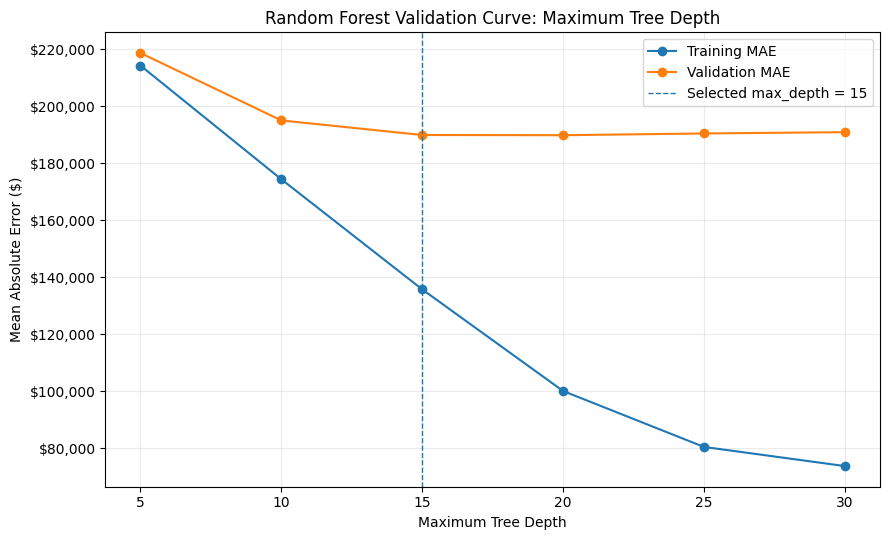

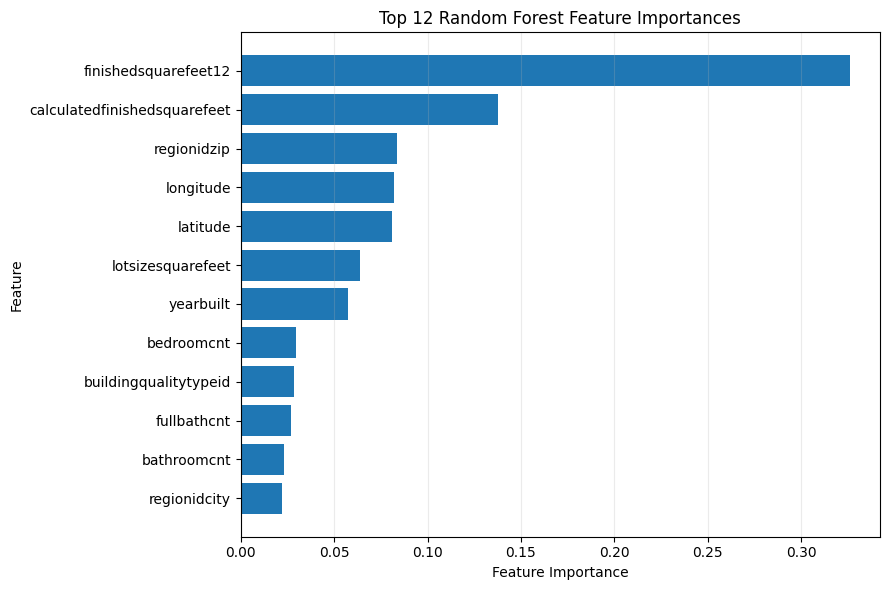

Figures saved:
figure1_rf_max_depth_validation.png
figure2_rf_feature_importance.png


In [26]:
# ==============================================
# Final Report Figures
# ==============================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# ------------------------------
# Figure 1: RF max_depth curve
# ------------------------------

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(
    rf_depth_sweep["parameter_value"],
    rf_depth_sweep["mean_train_mae"],
    marker="o",
    label="Training MAE"
)

ax.plot(
    rf_depth_sweep["parameter_value"],
    rf_depth_sweep["mean_cv_mae"],
    marker="o",
    label="Validation MAE"
)

ax.axvline(
    x=15,
    linestyle="--",
    linewidth=1,
    label="Selected max_depth = 15"
)

ax.set_title(
    "Random Forest Validation Curve: Maximum Tree Depth"
)
ax.set_xlabel("Maximum Tree Depth")
ax.set_ylabel("Mean Absolute Error ($)")

ax.yaxis.set_major_formatter(
    mticker.StrMethodFormatter("${x:,.0f}")
)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    "figure1_rf_max_depth_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------
# Figure 2: Top 12 feature importances
# ------------------------------------

top12_importance = fi_df.head(12).sort_values(
    "Importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top12_importance["Feature"],
    top12_importance["Importance"]
)

ax.set_title(
    "Top 12 Random Forest Feature Importances"
)
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "figure2_rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figures saved:")
print("figure1_rf_max_depth_validation.png")
print("figure2_rf_feature_importance.png")